# Data Merging & Feature Engineering

**Inputs:**  
- `data/processed/flight_features.csv` — 6.96M rows, 9 columns (from Student 1)  
- `data/processed/weather_features.csv` — hourly weather per airport per date  

**Output:** `data/processed/merged_dataset.csv` — single ready-to-preprocess dataset  

**Steps:**
1. Load both processed datasets
2. Aggregate weather to (airport, month, hour) profile
3. Left-join flights ← weather on `(origin, month, dep_hour)`
4. Report & impute missing weather values
5. Cap outliers on numerical columns (IQR)
6. Final checks and save

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

## 1 — Load Processed Datasets

In [15]:
flights = pd.read_csv('../data/processed/flight_features.csv')
weather_hourly = pd.read_csv('../data/processed/weather_features.csv')

print('=== Flights ===')
print(f'Shape: {flights.shape}')
print(f'Columns: {list(flights.columns)}')
print(flights.head(3))

print('\n=== Weather (hourly) ===')
print(f'Shape: {weather_hourly.shape}')
print(f'Columns: {list(weather_hourly.columns)}')
print(weather_hourly.head(3))

=== Flights ===
Shape: (6965267, 9)
Columns: ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed']
  airline origin dest  distance  dep_hour  day_of_week  month  is_weekend  \
0      9E    JFK  DTW     509.0        12            1      1           0   
1      9E    MSP  CLE     622.0        10            1      1           0   
2      9E    JFK  RIC     288.0        14            1      1           0   

   is_delayed  
0           0  
1           0  
2           0  

=== Weather (hourly) ===
Shape: (49980, 7)
Columns: ['iata', 'date', 'hour', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']
  iata        date  hour  precipitation  temperature_c  humidity_pct  \
0  DAL  2024-01-01     0       6.250919      16.380090     61.288195   
1  DAL  2024-01-01     1       4.374396      19.629655     59.651127   
2  DAL  2024-01-01     2       3.920242      15.518188     61.101467   

   wind_speed_kmh  
0       16.224433  
1

## 2 — Prepare Weather for Merge

The flight dataset has `month` and `dep_hour` but no full date (it was dropped to prevent leakage).  
We therefore aggregate the hourly weather data to a **(airport, month, hour)** profile — the mean weather conditions for a given airport at a given hour of a given month across all days in 2024.  
This gives each flight a realistic weather context at its departure airport and time.

In [16]:
# Extract month from the date column
weather_hourly['date'] = pd.to_datetime(weather_hourly['date'])
weather_hourly['month'] = weather_hourly['date'].dt.month

print(f'Month range: {weather_hourly["month"].min()} – {weather_hourly["month"].max()}')
print(f'Airports covered: {sorted(weather_hourly["iata"].unique())}')
print(f'Total airports: {weather_hourly["iata"].nunique()}')

Month range: 1 – 5
Airports covered: ['DAL', 'DFW', 'EWR', 'HOU', 'IAH', 'JFK', 'LAX', 'LGA', 'MDW', 'ORD', 'PHL', 'PHX', 'SAN', 'SAT', 'SJC']
Total airports: 15


In [17]:
# Aggregate to (iata, month, hour) — one representative row per combination
weather_monthly = (
    weather_hourly
    .groupby(['iata', 'month', 'hour'], as_index=False)
    .agg(
        precipitation  = ('precipitation',  'mean'),
        temperature_c  = ('temperature_c',  'mean'),
        humidity_pct   = ('humidity_pct',   'mean'),
        wind_speed_kmh = ('wind_speed_kmh', 'mean')
    )
)

# Rename to match flight column names before join
weather_monthly.rename(columns={'iata': 'origin', 'hour': 'dep_hour'}, inplace=True)

print(f'Weather monthly profile shape: {weather_monthly.shape}')
print(f'Unique airports: {weather_monthly["origin"].nunique()}')
print(weather_monthly.head())

Weather monthly profile shape: (1800, 7)
Unique airports: 15
  origin  month  dep_hour  precipitation  temperature_c  humidity_pct  \
0    DAL      1         0       5.089635      14.960893     60.341404   
1    DAL      1         1       5.064723      15.722687     59.410106   
2    DAL      1         2       4.889837      15.042225     60.337715   
3    DAL      1         3       5.035803      14.992242     58.878307   
4    DAL      1         4       5.039032      14.891266     59.442087   

   wind_speed_kmh  
0       14.822125  
1       15.034189  
2       14.510550  
3       15.326828  
4       15.137292  


## 3 — Merge Flights ← Weather

In [18]:
# Left join: every flight row is kept; weather columns are NaN when origin not in weather data
merged = flights.merge(
    weather_monthly,
    on=['origin', 'month', 'dep_hour'],
    how='left'
)

print(f'Flights in:  {len(flights):,}')
print(f'Merged out:  {len(merged):,}')
print(f'Columns:     {list(merged.columns)}')

Flights in:  6,965,267
Merged out:  6,965,267
Columns:     ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']


In [19]:
# --- Coverage report ---
weather_cols = ['precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']

n_matched   = merged['precipitation'].notna().sum()
n_total     = len(merged)
pct_matched = n_matched / n_total * 100

print(f'Flights WITH weather data   : {n_matched:>10,}  ({pct_matched:.1f}%)')
print(f'Flights WITHOUT weather data: {n_total - n_matched:>10,}  ({100 - pct_matched:.1f}%)')
print()

# Which origin airports matched?
covered_airports = weather_monthly['origin'].unique()
all_origins      = flights['origin'].unique()
print(f'Origin airports in flight data : {len(all_origins)}')
print(f'Origin airports with weather   : {len(covered_airports)}')
print(f'Covered airports: {sorted(covered_airports)}')

Flights WITH weather data   :    787,988  (11.3%)
Flights WITHOUT weather data:  6,177,279  (88.7%)

Origin airports in flight data : 348
Origin airports with weather   : 15
Covered airports: ['DAL', 'DFW', 'EWR', 'HOU', 'IAH', 'JFK', 'LAX', 'LGA', 'MDW', 'ORD', 'PHL', 'PHX', 'SAN', 'SAT', 'SJC']


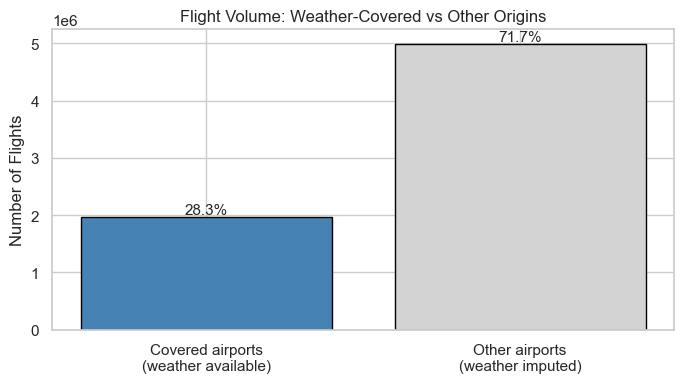

In [20]:
# Visualise coverage: how many flights depart from each weather-covered airport?
origin_counts = flights['origin'].value_counts()
covered_counts   = origin_counts[origin_counts.index.isin(covered_airports)]
uncovered_counts = origin_counts[~origin_counts.index.isin(covered_airports)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Covered airports\n(weather available)', 'Other airports\n(weather imputed)'],
       [covered_counts.sum(), uncovered_counts.sum()],
       color=['steelblue', 'lightgrey'], edgecolor='black')
ax.set_title('Flight Volume: Weather-Covered vs Other Origins')
ax.set_ylabel('Number of Flights')
for p in ax.patches:
    ax.annotate(f'{p.get_height()/len(flights)*100:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/reports/weather_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Impute Missing Weather Values

Flights whose origin airport is not in the weather dataset receive the **global mean** of each weather feature.  
This is a conservative imputation that keeps all 6.96M flight rows intact.

In [21]:
print('=== Missing values BEFORE imputation ===')
print(merged[weather_cols].isnull().sum().to_string())

imputed_means = {}
for col in weather_cols:
    global_mean = merged[col].mean()
    imputed_means[col] = round(global_mean, 4)
    merged[col] = merged[col].fillna(global_mean)

print('\n=== Imputed with global means ===')
for col, mean_val in imputed_means.items():
    print(f'  {col:<20}: {mean_val}')

print('\n=== Missing values AFTER imputation ===')
print(merged[weather_cols].isnull().sum().to_string())

=== Missing values BEFORE imputation ===
precipitation     6177279
temperature_c     6177279
humidity_pct      6177279
wind_speed_kmh    6177279

=== Imputed with global means ===
  precipitation       : 5.0969
  temperature_c       : 14.8037
  humidity_pct        : 60.0402
  wind_speed_kmh      : 15.0075

=== Missing values AFTER imputation ===
precipitation     0
temperature_c     0
humidity_pct      0
wind_speed_kmh    0


## 5 — Outlier Handling (IQR Capping)

We **cap** (winsorise) rather than drop outliers to preserve dataset size.  
Values below Q1 − 1.5×IQR are set to that lower bound; values above Q3 + 1.5×IQR are set to the upper bound.

In [22]:
def cap_outliers_iqr(df, col, multiplier=1.5):
    """Winsorise a column using the IQR method. Returns (n_capped, lower, upper)."""
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0, q1, q3
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    mask  = (df[col] < lower) | (df[col] > upper)
    n_capped = int(mask.sum())
    df[col]  = df[col].clip(lower=lower, upper=upper)
    return n_capped, lower, upper


# Numerical columns that may carry outliers worth capping
num_cols_to_cap = ['distance', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']

print(f'{"Column":<22} {"Capped":>10} {"Lower":>10} {"Upper":>10}')
print('-' * 56)
for col in num_cols_to_cap:
    n, lo, hi = cap_outliers_iqr(merged, col)
    pct = n / len(merged) * 100
    print(f'{col:<22} {n:>8,} ({pct:.2f}%)   [{lo:.2f}, {hi:.2f}]')

Column                     Capped      Lower      Upper
--------------------------------------------------------
distance                413,198 (5.93%)   [-606.00, 2074.00]
precipitation                 0 (0.00%)   [5.10, 5.10]
temperature_c                 0 (0.00%)   [14.80, 14.80]
humidity_pct                  0 (0.00%)   [60.04, 60.04]
wind_speed_kmh                0 (0.00%)   [15.01, 15.01]


## 6 — Final Dataset Inspection

In [23]:
print(f'Final shape : {merged.shape}')
print(f'\nColumns     : {list(merged.columns)}')
print(f'\nMissing values:\n{merged.isnull().sum().to_string()}')
print(f'\nTarget distribution:')
vc = merged['is_delayed'].value_counts()
for label, count in vc.items():
    print(f'  {label} → {count:,} ({count/len(merged)*100:.2f}%)')

Final shape : (6965267, 13)

Columns     : ['airline', 'origin', 'dest', 'distance', 'dep_hour', 'day_of_week', 'month', 'is_weekend', 'is_delayed', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']

Missing values:
airline           0
origin            0
dest              0
distance          0
dep_hour          0
day_of_week       0
month             0
is_weekend        0
is_delayed        0
precipitation     0
temperature_c     0
humidity_pct      0
wind_speed_kmh    0

Target distribution:
  0 → 5,561,879 (79.85%)
  1 → 1,403,388 (20.15%)


In [24]:
print('=== Numerical Summary ===')
num_cols = ['distance', 'dep_hour', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']
print(merged[num_cols].describe().round(3).to_string())

=== Numerical Summary ===
          distance     dep_hour  precipitation  temperature_c  humidity_pct  wind_speed_kmh
count  6965267.000  6965267.000    6965267.000    6965267.000   6965267.000     6965267.000
mean       810.525       12.992          5.097         14.804        60.040          15.007
std        530.048        4.898          0.165          0.365         0.204           0.102
min         11.000        0.000          4.664          8.873        57.553          13.918
25%        399.000        9.000          5.097         14.804        60.040          15.007
50%        680.000       13.000          5.097         14.804        60.040          15.007
75%       1069.000       17.000          5.097         14.804        60.040          15.007
max       2074.000       24.000          7.724         17.007        61.834          15.874


In [25]:
print(merged.head())

  airline origin dest  distance  dep_hour  day_of_week  month  is_weekend  \
0      9E    JFK  DTW     509.0        12            1      1           0   
1      9E    MSP  CLE     622.0        10            1      1           0   
2      9E    JFK  RIC     288.0        14            1      1           0   
3      9E    RIC  JFK     288.0        16            1      1           0   
4      9E    DTW  MKE     237.0        10            1      1           0   

   is_delayed  precipitation  temperature_c  humidity_pct  wind_speed_kmh  
0           0       5.099703      14.905590     60.748897       14.919450  
1           0       5.096906      14.803655     60.040201       15.007456  
2           0       5.081113      14.925762     58.949594       15.131454  
3           0       5.096906      14.803655     60.040201       15.007456  
4           0       5.096906      14.803655     60.040201       15.007456  


## 7 — Save Merged Dataset

In [26]:
output_path = '../data/processed/merged_dataset.csv'
merged.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'Shape: {merged.shape}')
print(f'\nFinal columns:')
for i, col in enumerate(merged.columns, 1):
    dtype = str(merged[col].dtype)
    print(f'  {i:2}. {col:<22} ({dtype})')

Saved: ../data/processed/merged_dataset.csv
Shape: (6965267, 13)

Final columns:
   1. airline                (object)
   2. origin                 (object)
   3. dest                   (object)
   4. distance               (float64)
   5. dep_hour               (int64)
   6. day_of_week            (int64)
   7. month                  (int64)
   8. is_weekend             (int64)
   9. is_delayed             (int64)
  10. precipitation          (float64)
  11. temperature_c          (float64)
  12. humidity_pct           (float64)
  13. wind_speed_kmh         (float64)
